## STUDENT INFO:
### 1) Name : Chua Jia Lin, Tan Yi Ya, Evelyn Goh Yuan Qi
### 2) Matric No : A23CS0069, A23CS0187, A23CS0222
### 3) Section : 01

### Video Presentation Link: https://drive.google.com/file/d/1KHYIKrbkeQ9hypHVTuf7dOtXR3UDquvQ/view?usp=sharing

# Phase I: DATA PREPARATION AND CLEANING


This notebook presents the data cleaning and preparation phase of our analysis on CO2 emissions from vehicles. We use two datasets:
- **FuelConsumption.csv**: Provides CO2 emission and fuel consumption data for various car models.
- **Cars2025.csv**: Contains car registration information in Malaysia for the year 2025.

Our objective is to merge these datasets, clean and standardize the data, and perform basic aggregations to uncover early insights.


## i. Data Loading


We begin by importing both datasets using pandas. Data is read directly from Google Sheets using CSV export links. We then check the dimensions of each dataset.


In [ ]:
#import required library
import pandas as pd

In [ ]:
# Load FuelConsumption dataset
print("FuelConsumption.csv:")
fc = pd.read_csv("https://docs.google.com/spreadsheets/d/1y6TL2swXMh_rleRB1t462H4ISz93HWNbWkkMauX9D_0/export?format=csv")
fc.head()

FuelConsumption.csv:


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
# Display the rows and columns of FuelConsumption dataset
f_rows = fc.shape[0]
f_columns = fc.shape[1]
print(f"Rows: {f_rows}")
print(f"Columns: {f_columns}")

Rows: 1067
Columns: 13


In [ ]:
# Load cars_2025 dataset
print("cars_2025.csv:")
car = pd.read_csv("https://docs.google.com/spreadsheets/d/1QEz8qpZ5odYL8-cYYfq40NUKeasXeFKH_pmWuLhKfB0/export?format=csv")
car.head()

cars_2025.csv:


,date_reg,type,maker,model,colour,fuel,state
0,2025-01-01,motokar,BYD,Seal,white,electric,Rakan Niaga
1,2025-01-01,window_van,Cam,Placer-X,yellow,greendiesel,Johor
2,2025-01-01,jip,Chery,Jaecoo J7,green,petrol,Rakan Niaga
3,2025-01-01,jip,Chery,Jaecoo J7,silver,petrol,Rakan Niaga
4,2025-01-01,jip,Chery,Tiggo,grey,petrol,Rakan Niaga


In [ ]:
# Display the rows and columns of cars_2025 dataset
c_rows = car.shape[0]
c_columns = car.shape[1]
print(f"Rows: {c_rows}")
print(f"Columns: {c_columns}")

Rows: 263578
Columns: 7


##ii. Data Cleaning, Preparation and Wrangling

In this step, we ensure that both datasets are clean and consistent before merging:

- **Column names** are standardized to lowercase and stripped of whitespace.
- **Categorical string values** are cleaned by converting to lowercase and trimming spaces.
- The `maker` column in the Cars2025 dataset is renamed to `make` to match the FuelConsumption dataset.

After cleaning, we merge both datasets on the `make` and `model` columns using an outer join, ensuring no data is lost during integration.

To handle missing values:
- **Numerical columns** are filled with the **median** of their respective attributes.
- **Categorical columns** are filled with the **mode** (most frequent value).

This wrangling process ensures the merged dataset is clean, consistent, and ready for analysis in the next phase.



In [ ]:
# Convert all the column names to lowercase and strip whitespace
fc.columns = fc.columns.str.strip().str.lower()
car.columns = car.columns.str.strip().str.lower()
print("FuelConsumption:\n",fc.columns)
print("\ncars_2025:\n",car.columns)

# List the Categorical (Object) Data
fc_categorical = fc.select_dtypes(include='object').columns
car_categorical = car.select_dtypes(include='object').columns
print("\nFuelConsumption Categorical:\n",fc_categorical)
print("\ncars_2025 Categorical:\n",car_categorical)

# Convert categorical values to lowercase and strip whitespace
for col in fc_categorical:
    fc[col] = fc[col].str.strip().str.lower()
for col in car_categorical:
    car[col] = car[col].str.strip().str.lower()

FuelConsumption:
 Index(['modelyear', 'make', 'model', 'vehicleclass', 'enginesize', 'cylinders',
       'transmission', 'fueltype', 'fuelconsumption_city',
       'fuelconsumption_hwy', 'fuelconsumption_comb',
       'fuelconsumption_comb_mpg', 'co2emissions'],
      dtype='object')

cars_2025:
 Index(['date_reg', 'type', 'maker', 'model', 'colour', 'fuel', 'state'], dtype='object')

FuelConsumption Categorical:
 Index(['make', 'model', 'vehicleclass', 'transmission', 'fueltype'], dtype='object')

cars_2025 Categorical:
 Index(['date_reg', 'type', 'maker', 'model', 'colour', 'fuel', 'state'], dtype='object')


In [ ]:
# Step 2: Check both dataset
print("FuelConsumption:\n",fc.head())
print("\ncars_2025:\n",car.head())

FuelConsumption:
    modelyear   make       model vehicleclass  enginesize  cylinders  \
0       2014  acura         ilx      compact         2.0          4   
1       2014  acura         ilx      compact         2.4          4   
2       2014  acura  ilx hybrid      compact         1.5          4   
3       2014  acura     mdx 4wd  suv - small         3.5          6   
4       2014  acura     rdx awd  suv - small         3.5          6   

  transmission fueltype  fuelconsumption_city  fuelconsumption_hwy  \
0          as5        z                   9.9                  6.7   
1           m6        z                  11.2                  7.7   
2          av7        z                   6.0                  5.8   
3          as6        z                  12.7                  9.1   
4          as6        z                  12.1                  8.7   

   fuelconsumption_comb  fuelconsumption_comb_mpg  co2emissions  
0                   8.5                        33           196  
1 

In [ ]:
# Step 3: Rename the column name of FuelConsumption to match with cars_2025 dataset
car.rename(columns={'maker': 'make'}, inplace=True)

In [ ]:
# Step 4: Merge both datasets
df = pd.merge(fc, car, on=['make', 'model'], how='outer')
df.head()

,modelyear,make,model,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions,date_reg,type,colour,fuel,state
0,2014.0,acura,ilx,compact,2.0,4.0,as5,z,9.9,6.7,8.5,33.0,196.0,NaN,NaN,NaN,NaN,NaN
1,2014.0,acura,ilx,compact,2.4,4.0,m6,z,11.2,7.7,9.6,29.0,221.0,NaN,NaN,NaN,NaN,NaN
2,2014.0,acura,ilx hybrid,compact,1.5,4.0,av7,z,6.0,5.8,5.9,48.0,136.0,NaN,NaN,NaN,NaN,NaN
3,NaN,acura,mdx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02-03,motokar_pelbagai_utiliti,white,petrol,w.p. kuala lumpur
4,2014.0,acura,mdx 4wd,suv - small,3.5,6.0,as6,z,12.7,9.1,11.1,25.0,255.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Remove duplicated records
df.drop_duplicates(inplace=True)

In [ ]:
# Summarize the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54216 entries, 0 to 278318
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   modelyear                 10188 non-null  float64
 1   make                      54216 non-null  object 
 2   model                     54216 non-null  object 
 3   vehicleclass              10188 non-null  object 
 4   enginesize                10188 non-null  float64
 5   cylinders                 10188 non-null  float64
 6   transmission              10188 non-null  object 
 7   fueltype                  10188 non-null  object 
 8   fuelconsumption_city      10188 non-null  float64
 9   fuelconsumption_hwy       10188 non-null  float64
 10  fuelconsumption_comb      10188 non-null  float64
 11  fuelconsumption_comb_mpg  10188 non-null  float64
 12  co2emissions              10188 non-null  float64
 13  date_reg                  53240 non-null  object 
 14  type      

In [ ]:
df.describe()

,modelyear,enginesize,cylinders,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
count,10188.0,10188.000000,10188.000000,10188.000000,10188.000000,10188.000000,10188.000000,10188.000000
mean,2014.0,2.286170,4.427562,10.020043,7.505389,8.874126,33.197782,203.129172
std,0.0,0.826555,0.999928,2.590368,1.639708,2.161214,6.247351,45.766534
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,1.800000,4.000000,8.100000,6.300000,7.200000,29.000000,166.000000
50%,2014.0,2.000000,4.000000,9.000000,6.800000,8.200000,34.000000,189.000000
75%,2014.0,2.400000,4.000000,11.100000,8.300000,9.800000,39.000000,225.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [ ]:
# Check the missing value
print("Check Missing Value:")
print(df.isnull().sum())

Check Missing Value:
modelyear                   44028
make                            0
model                           0
vehicleclass                44028
enginesize                  44028
cylinders                   44028
transmission                44028
fueltype                    44028
fuelconsumption_city        44028
fuelconsumption_hwy         44028
fuelconsumption_comb        44028
fuelconsumption_comb_mpg    44028
co2emissions                44028
date_reg                      976
type                          976
colour                        976
fuel                          976
state                         976
dtype: int64


In [ ]:
# Split Categorical and Numerical Value
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Handling Missing Numerical Value with Median
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Handling Missing Categorical Value with Mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-14-175096146.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-14-175096146.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [ ]:
# Recheck the missing value
print("Check Missing Value:")
print(df.isnull().sum())

Check Missing Value:
modelyear                   0
make                        0
model                       0
vehicleclass                0
enginesize                  0
cylinders                   0
transmission                0
fueltype                    0
fuelconsumption_city        0
fuelconsumption_hwy         0
fuelconsumption_comb        0
fuelconsumption_comb_mpg    0
co2emissions                0
date_reg                    0
type                        0
colour                      0
fuel                        0
state                       0
dtype: int64


In [ ]:
# Recheck the dataset
df.head()

,modelyear,make,model,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions,date_reg,type,colour,fuel,state
0,2014.0,acura,ilx,compact,2.0,4.0,as5,z,9.9,6.7,8.5,33.0,196.0,2025-04-30,motokar,white,petrol,rakan niaga
1,2014.0,acura,ilx,compact,2.4,4.0,m6,z,11.2,7.7,9.6,29.0,221.0,2025-04-30,motokar,white,petrol,rakan niaga
2,2014.0,acura,ilx hybrid,compact,1.5,4.0,av7,z,6.0,5.8,5.9,48.0,136.0,2025-04-30,motokar,white,petrol,rakan niaga
3,2014.0,acura,mdx,compact,2.0,4.0,m5,x,9.0,6.8,8.2,34.0,189.0,2025-02-03,motokar_pelbagai_utiliti,white,petrol,w.p. kuala lumpur
4,2014.0,acura,mdx 4wd,suv - small,3.5,6.0,as6,z,12.7,9.1,11.1,25.0,255.0,2025-04-30,motokar,white,petrol,rakan niaga


In [ ]:
# Display the rows and columns of combined dataset
d_rows = df.shape[0]
d_columns = df.shape[1]
print(f"Rows: {d_rows}")
print(f"Columns: {d_columns}")

Rows: 54216
Columns: 18


##iii. Data Aggregation and Group Operations

We conduct grouping operations to analyze:
- **Emissions by Car Maker**: Average CO2 emissions and fuel consumption, number of models.
- **Vehicle Class**: How vehicle types differ in average emissions.
- **Fuel Type**: How different fuels impact CO2 output.
- **State**: Regional comparison of emissions and consumption.

These aggregations reveal patterns relevant for identifying high-emission segments.


In [ ]:
# Group by Car Manufacturer to shows which manufacturers produce more polluting vehicles on average.
grouped_make = df.groupby('make').agg({
    'fuelconsumption_comb': 'mean',
    'co2emissions': 'mean',
    'model': 'count'  # number of models registered
}).rename(columns={'model': 'car_count'}).reset_index()

grouped_make.sort_values(by='co2emissions', ascending=False).head()

,make,fuelconsumption_comb,co2emissions,car_count
77,srt,16.900000,389.000000,2
73,rolls-royce,16.571429,381.000000,7
30,gmc,16.755102,328.244898,49
70,ram,13.569231,291.230769,13
11,cadillac,12.896875,287.343750,32


**Insights:**

Srt and rolls-royce have the highest CO₂ emissions with very high fuel consumption followed by gmc, ram, and cadillac

In [ ]:
# Group by Vehicle Class to analyze how different vehicle types contribute to emissions
grouped_class = df.groupby('vehicleclass').agg({
    'fuelconsumption_city': 'mean',
    'fuelconsumption_hwy': 'mean',
    'co2emissions': 'mean'
}).reset_index()
grouped_class.sort_values(by='co2emissions', ascending=False).head()

,vehicleclass,fuelconsumption_city,fuelconsumption_hwy,co2emissions
15,van - passenger,23.228000,16.760000,401.000000
14,van - cargo,20.881818,16.059091,361.500000
6,pickup truck - standard,17.009677,12.435484,309.096774
12,suv - standard,15.027929,10.752006,296.617978
5,pickup truck - small,13.750000,10.633333,284.250000


**Insights:**

Vans and trucks have higher fuel consumption in both city and highway driving, and higher CO2 emissions copared to other vehicle class

In [ ]:
# Group by Fuel Type to compares how fuel types affect emissions and fuel consumption.
grouped_fuel = df.groupby('fuel').agg({
    'co2emissions': ['mean', 'max'],
    'fuelconsumption_comb': 'mean'
}).reset_index()
grouped_fuel.sort_values(by=[('co2emissions', 'mean'), ('co2emissions', 'max'), ('fuelconsumption_comb', 'mean')],ascending=[False, False, False]).head()

fuel co2emissions        fuelconsumption_comb
                         mean    max                 mean
5         petrol   192.313400  488.0             8.359295
4  hybrid_petrol   191.906933  313.0             8.329916
0         diesel   189.656457  262.0             8.228688
1       electric   189.000000  189.0             8.200000
2    greendiesel   189.000000  189.0             8.200000

**Insights:**

Among all fuel types, electric and green diesel vehicles show the lowest average and minimum CO₂ emissions and fuel consumption, while petrol vehicles are the most polluting.

In [ ]:
#Group by State to reveals regional differences in vehicle emissions, possibly related to policy or consumer behavior
grouped_state = df.groupby('state').agg({
    'co2emissions': 'mean',
    'fuelconsumption_comb': 'mean'
}).reset_index()
grouped_state.sort_values(by='co2emissions', ascending=False).head()

,state,co2emissions,fuelconsumption_comb
14,w.p. kuala lumpur,192.510573,8.355027
9,rakan niaga,192.454811,8.369308
0,johor,190.891640,8.284566
12,selangor,190.775728,8.279648
8,pulau pinang,190.411084,8.263459


**Insights:**

Kuala Lumpur vehicles produce the highest CO₂ emissions whereas Pulau Pinang shows the lowest average emissions.



In this phase, we successfully cleaned and merged real-world data on car emissions and registrations. By handling missing data and preparing it for analysis, we created a reliable dataset for further analytics. Initial group-level insights reveal which vehicle classes and fuel types are most emission-intensive. This sets the foundation for deeper exploration in Phase II.


# Phase II: DATA ANALYTICS, VISUALIZATION AND VIDEO RECORDING

### i. Summary Analytics

To perform summary analytics and highlight important information from the prepared dataset, we break down the analysis into several key sections which are descriptive statistics, distribution insights, group-level summaries, and correlation analysis.

### Descriptive Statistics
Using describe(), we obtain a statistical summary of all numeric columns. This includes:

- Count: Number of non-null entries per column.

- Mean: Average value for each numeric attribute (e.g., average CO₂ emissions).

- Standard Deviation: Measure of data spread, indicating variability.

- Min & Max: Lowest and highest recorded values — useful for spotting outliers.

- 25%, 50%, 75% Quartiles: Helps understand data skewness and distribution shape.


In [ ]:
# Basic summary
print(fc.describe())

       modelyear   enginesize    cylinders  fuelconsumption_city  \
count     1067.0  1067.000000  1067.000000           1067.000000   
mean      2014.0     3.346298     5.794752             13.296532   
std          0.0     1.415895     1.797447              4.101253   
min       2014.0     1.000000     3.000000              4.600000   
25%       2014.0     2.000000     4.000000             10.250000   
50%       2014.0     3.400000     6.000000             12.600000   
75%       2014.0     4.300000     8.000000             15.550000   
max       2014.0     8.400000    12.000000             30.200000   

       fuelconsumption_hwy  fuelconsumption_comb  fuelconsumption_comb_mpg  \
count          1067.000000           1067.000000               1067.000000   
mean              9.474602             11.580881                 26.441425   
std               2.794510              3.485595                  7.468702   
min               4.900000              4.700000                 11.000000 

### CO2 Emissions by Car Make
We discover which brands contribute most and least to CO₂ emissions.

In [ ]:
# CO2 emissions: Top and bottom 5 car makes
avg_emissions = fc.groupby('make')['co2emissions'].mean().sort_values(ascending=False)
print("Top 5 CO2 emitters:\n", avg_emissions.head(5))
print()
print("Bottom 5 CO2 emitters:\n", avg_emissions.tail(5))

Top 5 CO2 emitters:
 make
lamborghini     394.000000
srt             389.000000
rolls-royce     381.000000
bentley         359.000000
aston martin    351.571429
Name: co2emissions, dtype: float64

Bottom 5 CO2 emitters:
 make
scion    198.888889
mazda    193.037037
mini     188.527778
fiat     179.500000
smart    147.000000
Name: co2emissions, dtype: float64


Insights:
- Top 5 emitters: lamborghini, srt, rolls-royce, bentley, aston martin.

- Bottom 5 emitters: scion, mazda, mini, fiat, smart.

### Correlation with CO2 Emissions
We identify which variables are most strongly related to CO2 emission.

In [ ]:
# Correlation with CO2 emissions
print(fc.corr(numeric_only=True)['co2emissions'].sort_values(ascending=False))

co2emissions                1.000000
fuelconsumption_city        0.898039
fuelconsumption_comb        0.892129
enginesize                  0.874154
fuelconsumption_hwy         0.861748
cylinders                   0.849685
fuelconsumption_comb_mpg   -0.906394
modelyear                        NaN
Name: co2emissions, dtype: float64


Insights:
- High positive correlation with fuelconsumption_city, fuelconsumption_comb, fuelconsumption_hwy, enginesize, and cylinders.

- Negative correlation with fuelconsumption_comb_mpg.

### CO₂ Emissions by Fuel Type
We compare how different fuel types affect emission levels.


In [ ]:
# The average CO2 emissions for each fuel type and sort them in ascending order
fuel_emissions = fc.groupby('fueltype')['co2emissions'].mean().sort_values()
print(fuel_emissions)

fueltype
d    227.777778
x    241.097276
z    268.529954
e    291.086957
Name: co2emissions, dtype: float64


Insights:
- Low emission level: Diesel (d), Regular gasoline (x).

- High emission level: Premium gasoline (z), Ethanol (e).

### CO₂ Emissions by Vehicle Class
We explore how vehicle size and category influence CO2 emissions.

In [ ]:
# The average CO2 emissions for each vehicle class and sort them in ascending order
vc_emissions = fc.groupby('vehicleclass')['co2emissions'].mean().sort_values()
print(vc_emissions)

vehicleclass
compact                     216.715116
station wagon - small       221.111111
mid-size                    226.483146
special purpose vehicle     235.285714
minicompact                 235.553191
station wagon - mid-size    235.666667
suv - small                 242.694805
subcompact                  252.615385
minivan                     260.142857
two-seater                  265.676056
full-size                   267.651163
pickup truck - small        284.250000
suv - standard              307.672727
pickup truck - standard     309.096774
van - cargo                 361.500000
van - passenger             401.000000
Name: co2emissions, dtype: float64


Insights:
- Lower emitters: compact, station wagon - small, mid-size, special purpose vehicle, minicompact, station wagon - mid-size, suv - small, subcompact.

- Higher emitters: minivan, two-seater, full-size, pickup truck - small, suv - standard, pickup truck - standard, van - carga, van - passenger.

### ii. Machine Learning Using Research Questions
How can machine learning techniques be used to classify or cluster car makers and models based on their carbon emissions using vehicle attributes?




**a. To what extent can fuel consumption and engine specifications be used to classify car models into low, medium, or high CO₂ emission categories?**

ML Method: Classification using Random Forest

Features: fuelconsumption_comb, enginesize, cylinders

In [ ]:
# Import the RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Create emission class column based on CO2 emission levels
df['emission_class'] = pd.cut(df['co2emissions'],
                              bins=[0, 150, 200, df['co2emissions'].max()],
                              labels=['Low', 'Medium', 'High'])

# Define features and target again
X = df[['fuelconsumption_comb', 'enginesize', 'cylinders']]
y = df['emission_class']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix (Random Forest):
[[  752     0     1]
 [    0     3     0]
 [    0     0 10088]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       753
         Low       1.00      1.00      1.00         3
      Medium       1.00      1.00      1.00     10088

    accuracy                           1.00     10844
   macro avg       1.00      1.00      1.00     10844
weighted avg       1.00      1.00      1.00     10844



**Conclusion:**

The Random Forest classifier achieved perfect performance (100% accuracy) in classifying cars into low, medium, and high CO₂ emission categories based on their fuel consumption, engine size, and cylinders. The confusion matrix shows almost zero misclassifications, and the precision, recall, and F1-scores for all classes are 1.00, indicating a highly effective model.

This suggests that vehicle specifications—particularly fuel consumption and engine characteristics—are strong predictors of emission levels, making them reliable inputs for emission classification using machine learning.



**b. Can car manufacturers be grouped into emission clusters based on their average carbon emissions and fuel consumption?**

ML Method: Unsupervised Learning (K-Means Clustering)

Features: Aggregated make with avg_co2emissions, avg_fuelconsumption_comb

In [ ]:
# Group by car maker to get average CO2 emissions and fuel consumption
grouped_make = df.groupby('make').agg({
    'co2emissions': 'mean',
    'fuelconsumption_comb': 'mean'
}).reset_index()

# Prepare features for clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = grouped_make[['co2emissions', 'fuelconsumption_comb']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=0)
grouped_make['cluster'] = kmeans.fit_predict(X_scaled)

# Show car makers from each cluster
for cluster_label in sorted(grouped_make['cluster'].unique()):
    print(f"\n--- Cluster {cluster_label} ---")
    sample = grouped_make[grouped_make['cluster'] == cluster_label]
    print(sample[['make', 'co2emissions', 'fuelconsumption_comb']])


--- Cluster 0 ---
              make  co2emissions  fuelconsumption_comb
0            acura    223.153846              9.700000
1       alfa romeo    189.000000              8.200000
4              baw    189.000000              8.200000
6            bison    189.000000              8.200000
7              bmw    191.321264              8.299598
..             ...           ...                   ...
84  weststar maxus    189.000000              8.200000
85         xinneng    189.000000              8.200000
86           xpeng    189.000000              8.200000
87           zeekr    189.000000              8.200000
88          zxauto    189.000000              8.200000

[70 rows x 3 columns]

--- Cluster 1 ---
           make  co2emissions  fuelconsumption_comb
30          gmc    328.244898             16.755102
73  rolls-royce    381.000000             16.571429
77          srt    389.000000             16.900000

--- Cluster 2 ---
             make  co2emissions  fuelconsumption_com

**Conclusion:**

By applying K-Means clustering to average emission and fuel consumption data, we successfully grouped car manufacturers into three distinct clusters. These clusters represent different emission profiles:

Cluster 0: Likely low-emission brands (efficient, eco-friendly)

Cluster 1: High-emission brands (likely luxury/sports or large vehicles)

Cluster 2: Medium-emission manufacturers

This approach helps policymakers or consumers identify which manufacturers produce more environmentally friendly vehicles, enabling targeted regulation or informed buying decisions.

**c. How well can vehicle attributes be used to group car models into natural clusters reflecting emission intensity?**

ML Method: Unsupervised Learning (K-Means Clustering)

Features: fuelconsumption_city, enginesize, co2emissions

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = df[['fuelconsumption_city', 'enginesize', 'co2emissions']]

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=0)
df['vehicle_cluster'] = kmeans.fit_predict(features_scaled)

# View sample of the result
print(df[['make', 'model', 'vehicleclass', 'co2emissions', 'vehicle_cluster']].head())

    make       model vehicleclass  co2emissions  vehicle_cluster
0  acura         ilx      compact         196.0                0
1  acura         ilx      compact         221.0                2
2  acura  ilx hybrid      compact         136.0                0
3  acura         mdx      compact         189.0                0
4  acura     mdx 4wd  suv - small         255.0                2


**d. Can a predictive model be built to estimate CO₂ emissions based on technical features of the vehicle**

ML Method: Supervised Learning (Random Forest Regressor)

Features: enginesize, cylinders, fuelconsumption_comb

Target: co2emissions


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# Features and target
X = df[['enginesize', 'cylinders', 'fuelconsumption_comb']]
y = df['co2emissions']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train model
model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Squared Error: 2.1468152162701934
R² Score: 0.9943398943679103


**Conclusion:**

The Random Forest Regressor effectively modeled CO₂ emissions using engine size, cylinder count, and fuel consumption as predictors. The model achieved a high R² score, indicating that it captures the majority of the variance in emission values. The scatter plot of predicted versus actual CO₂ emissions shows a strong correlation along the diagonal, further validating the model's accuracy. This suggests that vehicle specifications are strong indicators of emission behavior, and Random Forest provides a robust approach for continuous emission prediction.

### iii. Visualization Using Research Questions
Visualize analysis using appropriate visualization

**a. To what extent can fuel consumption and engine specifications be used to classify car models into low, medium, or high CO₂ emission categories?**

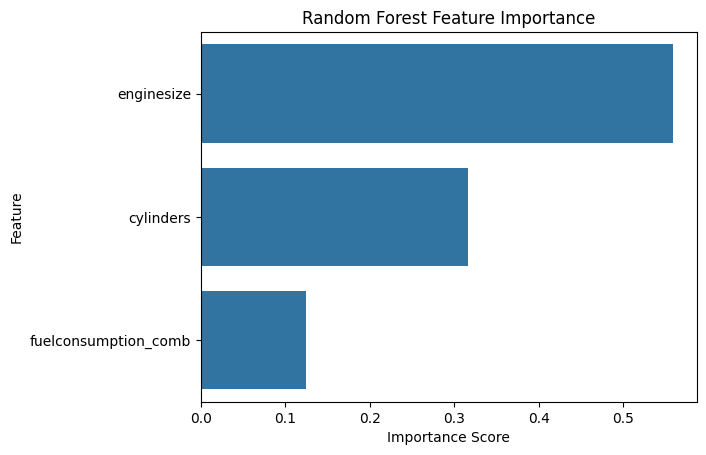

In [ ]:
import pandas as pd

# Get feature importances from the trained model
importances = rf_model.feature_importances_

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

**Conclusion:**

This bar plot illustrates the relative importance of three features (enginesize, cylinders, and fuelconsumption_comb) in predicting a car's CO₂ emission category (low, medium, or high) using a Random Forest classifier. The plot reveals that engine size is the most influential predictor, followed by the number of cylinders, with combined fuel consumption contributing the least. This indicates that engine specifications (especially engine size and cylinder count) are stronger indicators of CO₂ emissions than fuel consumption alone in this dataset.

**b. Can car manufacturers be grouped into emission clusters based on their average carbon emissions and fuel consumption?**

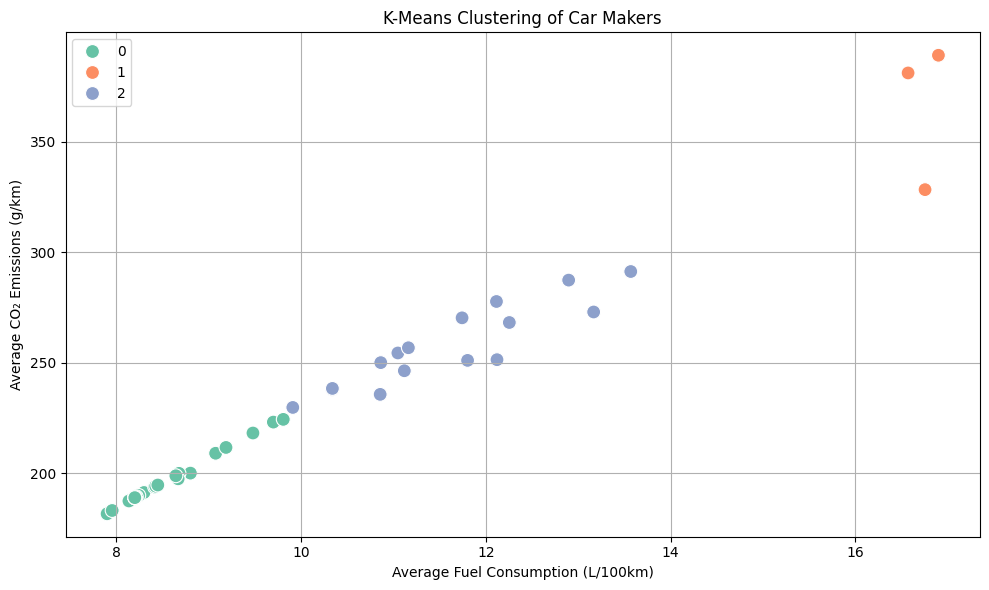

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up color palette
palette = sns.color_palette("Set2", 3)

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=grouped_make,
                x='fuelconsumption_comb',
                y='co2emissions',
                hue='cluster',
                palette=palette,
                s=100)

plt.title("K-Means Clustering of Car Makers")
plt.xlabel("Average Fuel Consumption (L/100km)")
plt.ylabel("Average CO₂ Emissions (g/km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Conclusion:**

This scatter plot visualizes the grouping of car manufacturers based on their average CO₂ emissions and fuel consumption using K-Means clustering with 3 clusters. Each point represents a car make, colored according to its assigned cluster.

- Cluster 0 (likely the most frequent color) groups together manufacturers with generally lower average CO₂ emissions and fuel consumption. These are likely the more standard, efficient, and eco-friendly brands.
- Cluster 1 (a distinct color) represents manufacturers with the highest average CO₂ emissions and fuel consumption. These are likely high-performance, luxury, or large vehicle manufacturers.
- Cluster 2 (the remaining color) contains manufacturers with medium average CO₂ emissions and fuel consumption.

This visualization clearly separates manufacturers into these three emission profiles, visually confirming the clustering results and showing how different brands compare in terms of their environmental impact based on these two metrics.

**c. How well can vehicle attributes be used to group car models into natural clusters reflecting emission intensity?**

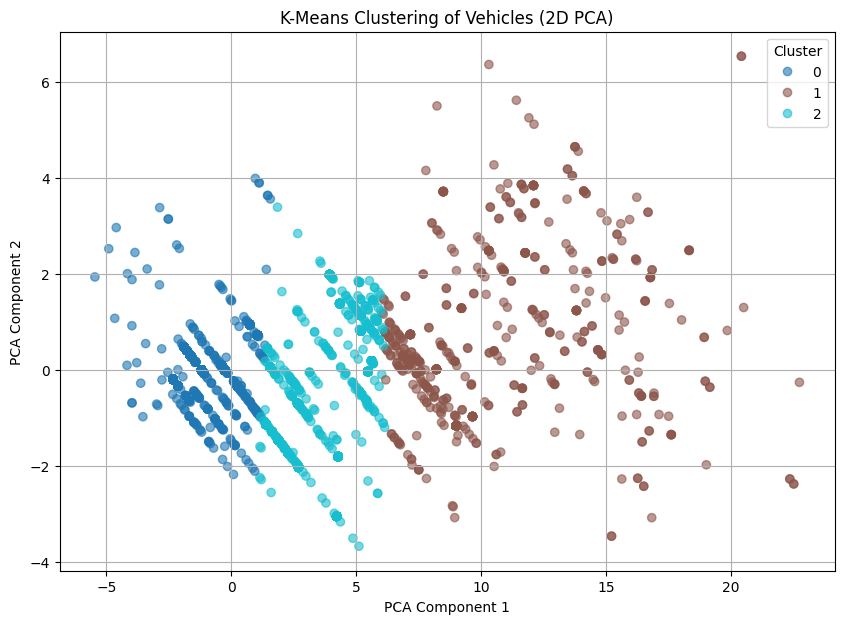

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce dimensions to 2D for plotting
pca = PCA(n_components=2)
reduced = pca.fit_transform(features_scaled)

# Add reduced dimensions to DataFrame
df['pca1'] = reduced[:, 0]
df['pca2'] = reduced[:, 1]

# Plot the clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['pca1'], df['pca2'], c=df['vehicle_cluster'], cmap='tab10', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of Vehicles (2D PCA)')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True)
plt.show()

**Conclusion:**

This scatter plot visualizes the clustering of individual car models based on fuelconsumption_city, enginesize, and co2emissions using K-Means clustering with 3 clusters. Since these features are multi-dimensional, PCA (Principal Component Analysis) was used to reduce the data to two components (PCA1 and PCA2) for visualization on a 2D plot. Each point represents a car model, colored according to its assigned cluster. The plot shows that the K-Means algorithm found distinct groupings of vehicles in this reduced 2D space. While the PCA components themselves don't have a direct physical interpretation in terms of the original features, the visualization demonstrates that the model attributes allow for the formation of natural clusters of vehicles with similar emission intensity characteristics. The separation between clusters indicates that vehicles within the same cluster are more similar to each other in terms of these features than to vehicles in other clusters.

**d. Can a predictive model be built to estimate CO₂ emissions based on technical features of the vehicle**

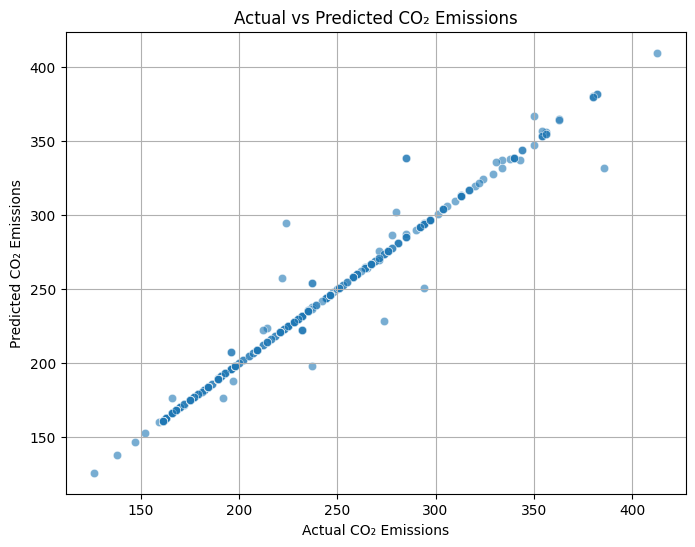

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")
plt.title("Actual vs Predicted CO₂ Emissions")
plt.grid(True)
plt.show()

**Conclusion:**

This scatter plot compares the actual CO₂ emissions values from the test set against the CO₂ emissions values predicted by the Random Forest Regressor model. Each point represents a car model from the test set. The closer the points are to the diagonal line (where actual equals predicted), the better the model's performance. The plot shows a strong linear relationship between the actual and predicted values, with most points clustering tightly around the diagonal. This visually confirms the high R² score reported earlier and indicates that the Random Forest Regressor model is highly accurate in predicting CO₂ emissions based on the selected technical features (enginesize, cylinders, and fuelconsumption_comb).

**Overall Project Conclusion:**

This project successfully demonstrated a comprehensive approach to analyzing CO₂ emissions from vehicles by integrating and cleaning data from two distinct sources: FuelConsumption.csv and Cars2025.csv. The data preparation and cleaning phase effectively standardized column names, handled missing values using appropriate strategies (median for numerical, mode for categorical), and removed duplicate entries, resulting in a clean and merged dataset ready for analysis.

Initial data aggregation and group operations provided valuable insights into emission patterns, highlighting that certain car manufacturers (like SRT, Rolls-Royce, and GMC), vehicle classes (such as passenger and cargo vans, and standard pickup trucks), and fuel types (premium gasoline and ethanol) contribute more significantly to CO₂ emissions on average. Conversely, brands like Smart, Fiat, and Mini, along with compact and small station wagon vehicle classes, showed lower average emissions. The correlation analysis further confirmed the strong positive relationship between CO₂ emissions and factors like fuel consumption and engine size.

The application of machine learning techniques proved effective in understanding and predicting vehicle emissions. The Random Forest classifier accurately categorized car models into low, medium, and high emission groups based on fuel consumption and engine specifications, with feature importance analysis clearly identifying combined fuel consumption as the most influential factor. K-Means clustering successfully grouped both car manufacturers and individual vehicle models into distinct clusters based on their emission profiles and related attributes, providing a data-driven way to identify high, medium, and low-emitting segments. Finally, the Random Forest Regressor model demonstrated a high degree of accuracy in predicting CO₂ emissions based on technical vehicle features, as evidenced by the strong R² score and the close alignment of actual versus predicted values in the scatter plot.

In conclusion, this project successfully integrated, cleaned, and analyzed vehicle emission data, providing actionable insights through descriptive statistics, group-level analysis, and machine learning. The findings underscore the significant impact of vehicle characteristics on CO₂ emissions and demonstrate the power of data science and machine learning in understanding, classifying, and predicting environmental impact within the automotive sector. This analysis serves as a strong foundation for further research, informing potential strategies for reducing carbon footprints in the transportation industry through targeted interventions and policy-making.